# Generate_Data_v2.4.5

这个版本是在 `Generate_Data_v2.4.4.ipynb` 的基础上修正一个关键异常：

- `v2.4.4` 为了避免负的 `a`，使用了 `a_final = max(0.1, a_final)` 的硬截断；
- 这会导致大量 trial 堆积在 `a = 0.1`；
- 边界过低时，证据积累很容易在最开始几步就撞边界，于是出现过多的 `201-205ms` 极短 RT。

因此，`v2.4.5` 的核心修正是：

1. 保留 `NA / omission` 机制；
2. 去掉 `a=0.1` 的硬堆积；
3. 改用 **重采样（resampling）** 的方式生成正的 `a_final`，让分布更平滑、更接近 `v2.4.3` 的逻辑。

## 一、为什么 v2.4.4 和 v2.4.3 的逻辑不完全一致

两版的主干逻辑是一致的：

- 都是 `S2 机制函数 + GP 修正项 + DDM`；
- 都是用 `v_mix / a_mix` 生成 trial-level 参数；
- 都是 `z = a / 2` 进入仿真。

但 `v2.4.4` 多了一个重要差异：

- `v2.4.3`：如果 `a_final <= 0`，才把它替换成 `max(0.1, a_mix)`；
- `v2.4.4`：直接用 `a_final = max(0.1, a_final)`，把所有过小的 `a` 都压到 `0.1`。

这就是为什么 `v2.4.4` 会比 `v2.4.3` 更容易出现靠近 `t0` 下限的极短 RT。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from scipy.special import expit as sigmoid

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 120)

BASE_DIR = Path.cwd().parent.parent
OUT_DIR = BASE_DIR / '2_Data' / 'Generate_Data' / 'Generate_Data_v2.4.5_checks'
FIG_DIR = BASE_DIR / '3_Figures' / 'Generate_Data_v2.4.5_checks'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('数据保存目录:', OUT_DIR)
print('图表保存目录:', FIG_DIR)

数据保存目录: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Generate_Data_v2.4.5_checks
图表保存目录: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Generate_Data_v2.4.5_checks


In [2]:
# Hybrid GP generator
class HybridDDMParameterGenerator:
    def __init__(self, w=0.5):
        self.w = w
        kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-5)
        self.gp_v = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
        self.gp_a = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
        self.beta_v = np.array([0.01, 0.02, -0.01])
        self.beta_a = np.array([0.005, -0.01, 0.015])

    def sigmoid_part(self, X, beta):
        return sigmoid(X @ beta)

    def fit_gp(self, X, Y_v, Y_a):
        self.gp_v.fit(X, Y_v)
        self.gp_a.fit(X, Y_a)

    def predict_params(self, X):
        sig_v = self.sigmoid_part(X, self.beta_v)
        sig_a = self.sigmoid_part(X, self.beta_a)
        gp_v = self.gp_v.predict(X)
        gp_a = self.gp_a.predict(X)
        v = self.w * sig_v + (1 - self.w) * gp_v
        a = self.w * sig_a + (1 - self.w) * gp_a
        t0 = np.full(len(v), 0.2)
        z = a / 2.0
        return v, a, t0, z

def k_P(P, k_min=0.01, k_max=0.15, gamma=0.1, P0=32):
    return k_min + (k_max - k_min) / (1 + np.exp(-gamma * (P - P0)))

def v_P_Function(P, P1=4, k_min=0.01, k_max=0.15, gamma=0.1, P0=32):
    k = k_P(P, k_min, k_max, gamma, P0)
    return 1 / (1 + np.exp(-k * (P - P1)))

def compute_v_s2(T, P, condition_key, alaph1=1.5, alaph2=-0.4, gamma=0.2):
    T_0 = 100
    k_T = 0.01
    v_T = 1 / (1 + np.exp(-k_T * (T - T_0)))
    v_P = v_P_Function(P=P, P1=4, k_min=0.1, k_max=0.05, gamma=gamma, P0=32)
    v_0 = v_T * v_P * 3
    if condition_key == 1:
        return v_0 * (1 + alaph1)
    return v_0 * (1 + alaph2)

def compute_a_s2(M, beta1=0.2, beta2=0.0, k=0.01, M_0=600):
    a_0 = 1 / (1 + np.exp(-k * (M - M_0))) * 3
    if M > 600:
        return a_0 * (1 + beta1)
    return a_0 * (1 + beta2)

def normalize_PTW_to_unit(P, T, W):
    P_norm = (P - 75.0) / 75.0
    T_norm = (T - 305.0) / 295.0
    W_norm = (W - 850.0) / 650.0
    return P_norm, T_norm, W_norm

def compute_lapse_omission_prob(T_ms, W_ms, lapse_max=0.35, T_mid=80, W_mid=600, T_scale=25, W_scale=120):
    t_term = 1.0 / (1.0 + np.exp((T_ms - T_mid) / T_scale))
    w_term = 1.0 / (1.0 + np.exp((W_ms - W_mid) / W_scale))
    return float(lapse_max * t_term * w_term)

def sample_a_positive(a_mix, a_noise, a_floor=0.03, max_resample=30):
    # 用重采样代替硬截断，避免大量 trial 堆到同一个下界
    for _ in range(max_resample):
        a_candidate = np.random.normal(a_mix, a_noise)
        if a_candidate > a_floor:
            return a_candidate
    # 如果反复失败，再回退到接近 a_mix 的正值，而不是固定常数
    return max(a_floor + abs(np.random.normal(0, a_noise * 0.25)), a_mix * 0.5, a_floor)

def simulate_ddm_with_deadline(v, a, z, t0, deadline_s, dt=0.001):
    decision_budget = deadline_s - t0
    if np.isnan(decision_budget) or decision_budget <= dt:
        return np.nan, 0, 1, 'deadline'

    x = float(z)
    time = 0.0
    max_steps = int(decision_budget / dt)
    for _ in range(max_steps):
        dx = v * dt + np.sqrt(dt) * np.random.randn()
        x += dx
        time += dt
        if x >= a:
            return t0 + time, 1, 0, 'upper'
        if x <= 0:
            return t0 + time, 2, 0, 'lower'
    return np.nan, 0, 1, 'deadline'

def generate_dataset_s2_na_v245(
    n_subjects=50,
    trials_per_sub=60,
    w_gp=0.5,
    v_noise=1.0,
    a_noise=0.5,
    lapse_max=0.35,
    seed=None,
    save_path=None,
):
    if seed is not None:
        np.random.seed(seed)

    gen = HybridDDMParameterGenerator(w=w_gp)
    X_train = np.random.uniform(-1, 1, size=(50, 3))
    Y_v = np.sin(X_train[:, 0]) * 0.5 + 0.1 * np.random.randn(50)
    Y_a = 1.5 + 0.3 * np.cos(X_train[:, 1]) + 0.05 * np.random.randn(50)
    gen.fit_gp(X_train, Y_v, Y_a)

    rows = []
    for subj in range(1, n_subjects + 1):
        T = np.random.randint(10, 600)
        P = np.random.randint(0, 150)
        W = np.random.randint(200, 1500)
        M = T + W
        a_s2 = compute_a_s2(M)

        trials_per_condition = trials_per_sub // 2
        if trials_per_sub % 2 != 0:
            trials_per_condition += 1

        for condition_key in range(2):
            label = 'self' if condition_key == 1 else 'stranger'
            for trial_idx in range(trials_per_condition):
                v_s2 = compute_v_s2(T, P, condition_key)
                Pn, Tn, Wn = normalize_PTW_to_unit(P, T, W)
                X = np.array([[Pn, Tn, Wn]])
                v_gp, a_gp, t0_arr, _ = gen.predict_params(X)

                v_mix = w_gp * v_gp[0] + (1 - w_gp) * v_s2
                a_mix = w_gp * a_gp[0] + (1 - w_gp) * a_s2
                t0 = float(t0_arr[0])

                v_final = np.random.normal(v_mix, v_noise)
                a_final = sample_a_positive(a_mix, a_noise, a_floor=0.03)
                z_final = a_final / 2.0
                deadline_s = W / 1000.0

                p_lapse = compute_lapse_omission_prob(T, W, lapse_max=lapse_max)
                if np.random.rand() < p_lapse:
                    RT = np.nan
                    response = 0
                    omission = 1
                    omission_source = 'lapse'
                else:
                    RT, response, omission, omission_source = simulate_ddm_with_deadline(v_final, a_final, z_final, t0, deadline_s)

                rows.append({
                    'subject': subj,
                    'trial': trial_idx + 1,
                    'P': P,
                    'T': T,
                    'W': W,
                    'M': M,
                    'label': label,
                    'v': v_final,
                    'a': a_final,
                    't0': t0,
                    'z': z_final,
                    'RT': RT,
                    'response': response,
                    'correct': 1 if response == 1 else 0,
                    'responded': int(omission == 0),
                    'omission': omission,
                    'omission_source': omission_source,
                    'deadline_s': deadline_s,
                    'p_lapse': p_lapse,
                    'v_s2': v_s2,
                    'a_s2': a_s2,
                    'v_gp_raw': v_gp[0],
                    'a_gp_raw': a_gp[0],
                    'v_mix': v_mix,
                    'a_mix': a_mix,
                })

    df = pd.DataFrame(rows)
    if save_path is None:
        save_path = OUT_DIR / 'gp_ddm_v2.4.5_large.csv'
    else:
        save_path = Path(save_path)
    df.to_csv(save_path, index=False)
    return df, gen

In [3]:
# 运行生成
df, gen = generate_dataset_s2_na_v245(
    n_subjects=2000,
    trials_per_sub=60,
    w_gp=0.5,
    lapse_max=0.35,
    seed=42,
)

out_csv = OUT_DIR / 'gp_ddm_v2.4.5_large.csv'
df.to_csv(out_csv, index=False)
print('Saved CSV to', out_csv)

df = df.copy()
df['RT_ms'] = df['RT'] * 1000
df['RT_ms_answered'] = np.where(df['responded'] == 1, df['RT_ms'], np.nan)
df['ACC_answered'] = np.where(df['responded'] == 1, df['correct'], np.nan)

print('\nOverall trials:', len(df))
print('Responded rate:', df['responded'].mean())
print('Omission rate :', df['omission'].mean())
print('Answered RT mean (s):', df.loc[df['responded'] == 1, 'RT'].mean())
print('Answered ACC:', df.loc[df['responded'] == 1, 'correct'].mean())

small_rt = df['RT'].between(0.201, 0.205, inclusive='both')
print('\n201-205ms trial count:', int(small_rt.sum()))
print('201-205ms proportion among answered:', float(small_rt.sum() / max(df['RT'].notna().sum(), 1)))
print('a <= 0.1 proportion:', float((df['a'] <= 0.1).mean()))

print('\nOmission by label:')
display(df.groupby('label')['omission'].mean().round(4))

c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Saved CSV to d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Generate_Data_v2.4.5_checks\gp_ddm_v2.4.5_large.csv

Overall trials: 120000
Responded rate: 0.5705666666666667
Omission rate : 0.42943333333333333
Answered RT mean (s): 0.5629002745808263
Answered ACC: 0.8784979844598937

201-205ms trial count: 247
201-205ms proportion among answered: 0.003607524683063621
a <= 0.1 proportion: 0.001525

Omission by label:


label
self        0.3098
stranger    0.5491
Name: omission, dtype: float64

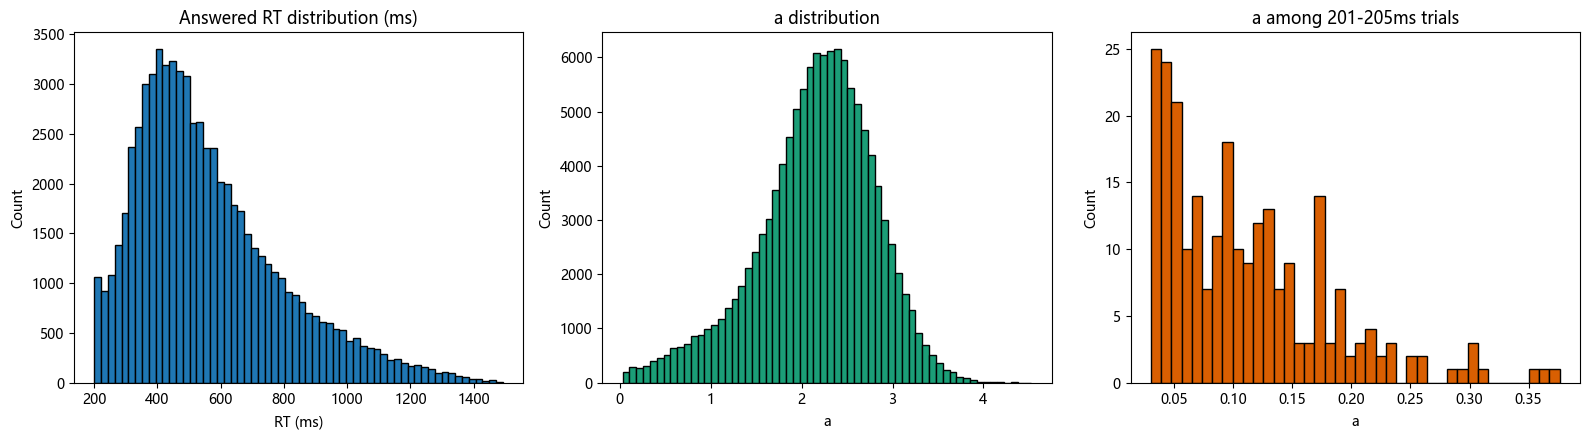

In [4]:
# 诊断图：对比极短 RT 与 a 分布
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(df.loc[df['responded'] == 1, 'RT_ms'], bins=60, edgecolor='black')
axes[0].set_title('Answered RT distribution (ms)')
axes[0].set_xlabel('RT (ms)')
axes[0].set_ylabel('Count')

axes[1].hist(df['a'], bins=60, edgecolor='black', color='#1b9e77')
axes[1].set_title('a distribution')
axes[1].set_xlabel('a')
axes[1].set_ylabel('Count')

small = df[df['RT'].between(0.201, 0.205, inclusive='both')]
axes[2].hist(small['a'], bins=40, edgecolor='black', color='#d95f02')
axes[2].set_title('a among 201-205ms trials')
axes[2].set_xlabel('a')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(FIG_DIR / 'rt_a_diagnostics_v2.4.5.png', dpi=220, bbox_inches='tight')
plt.show()

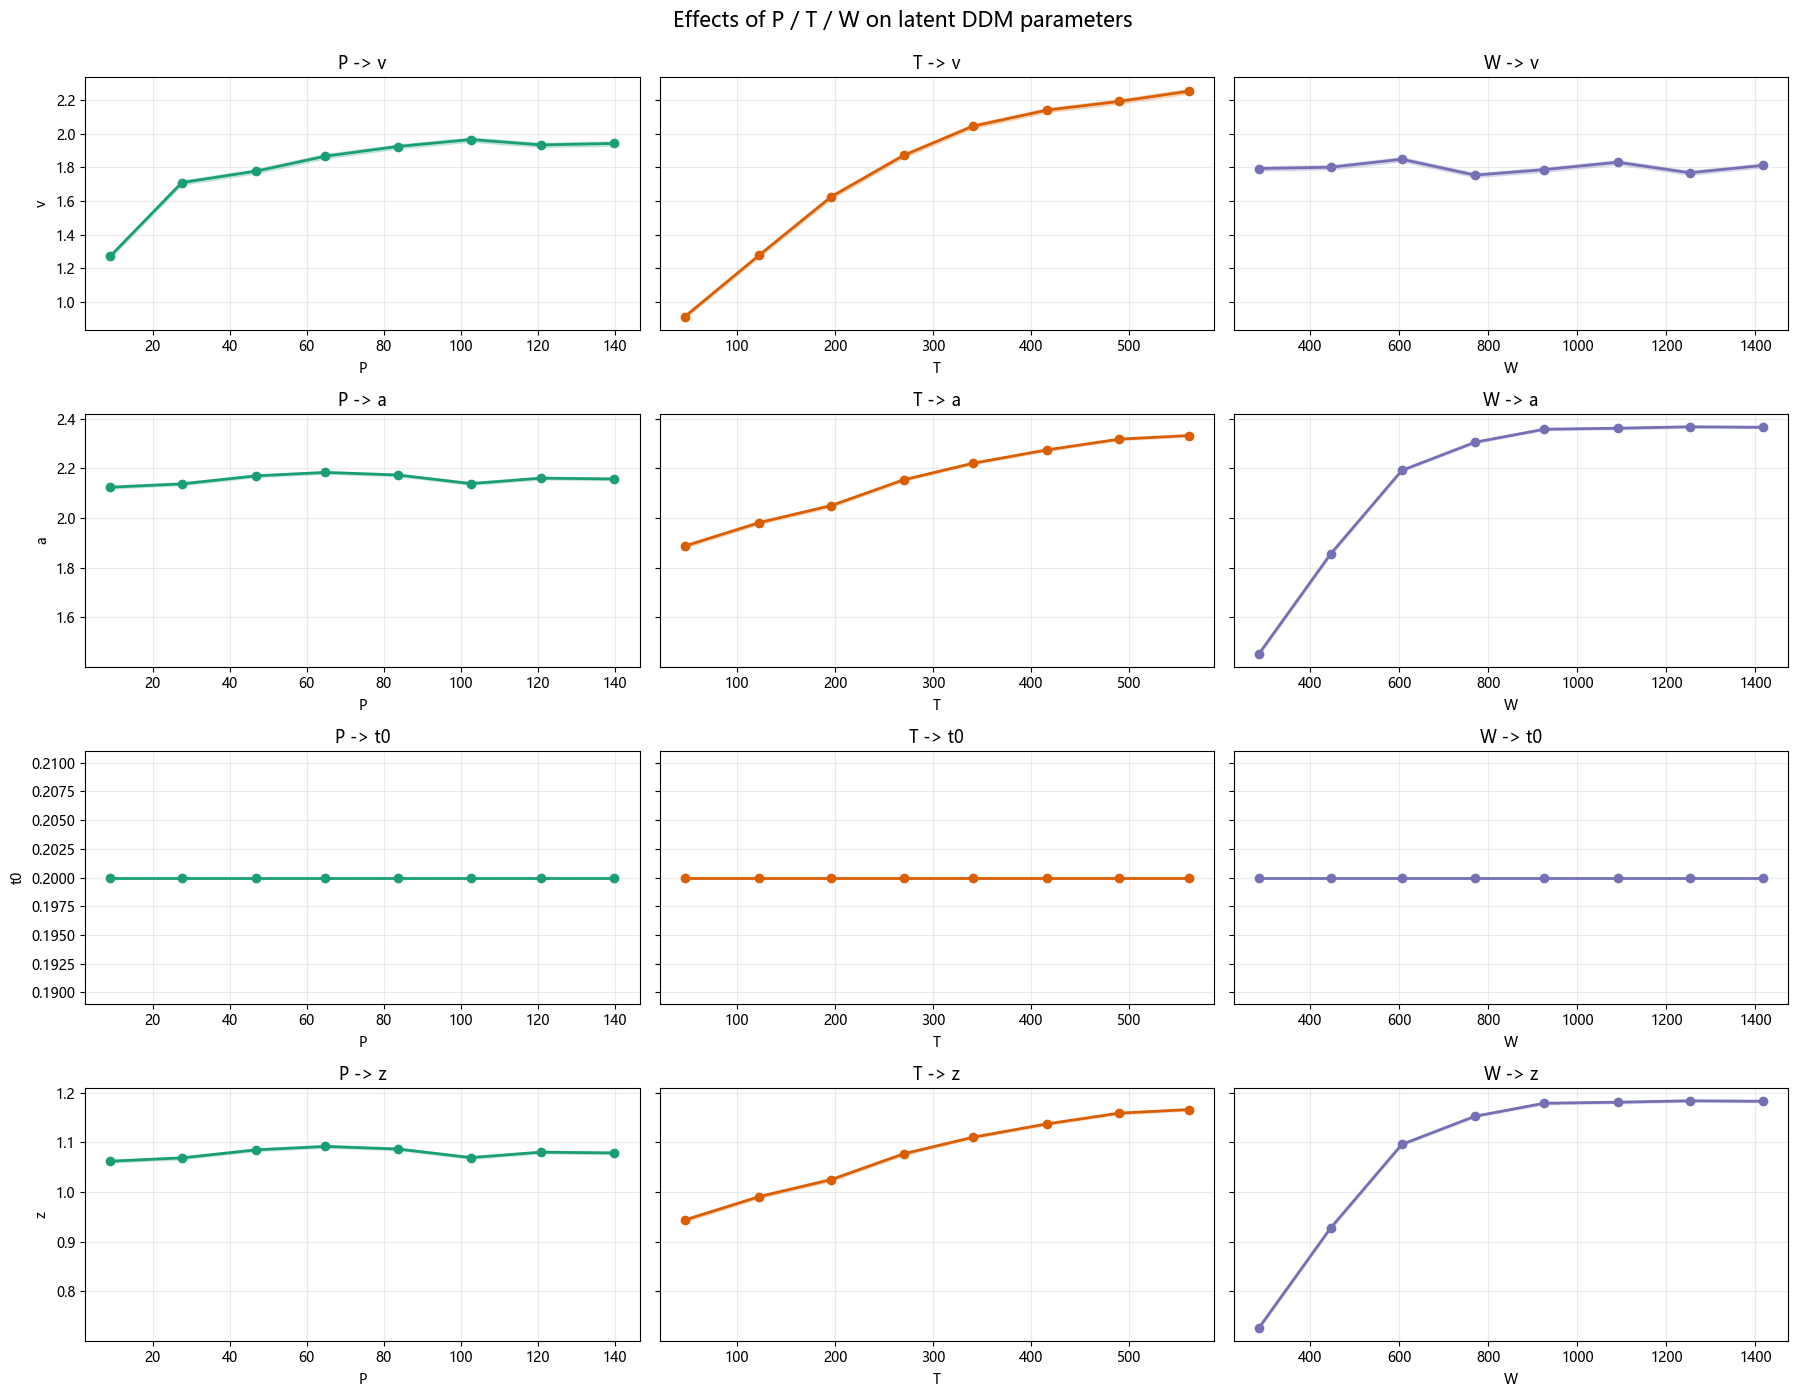

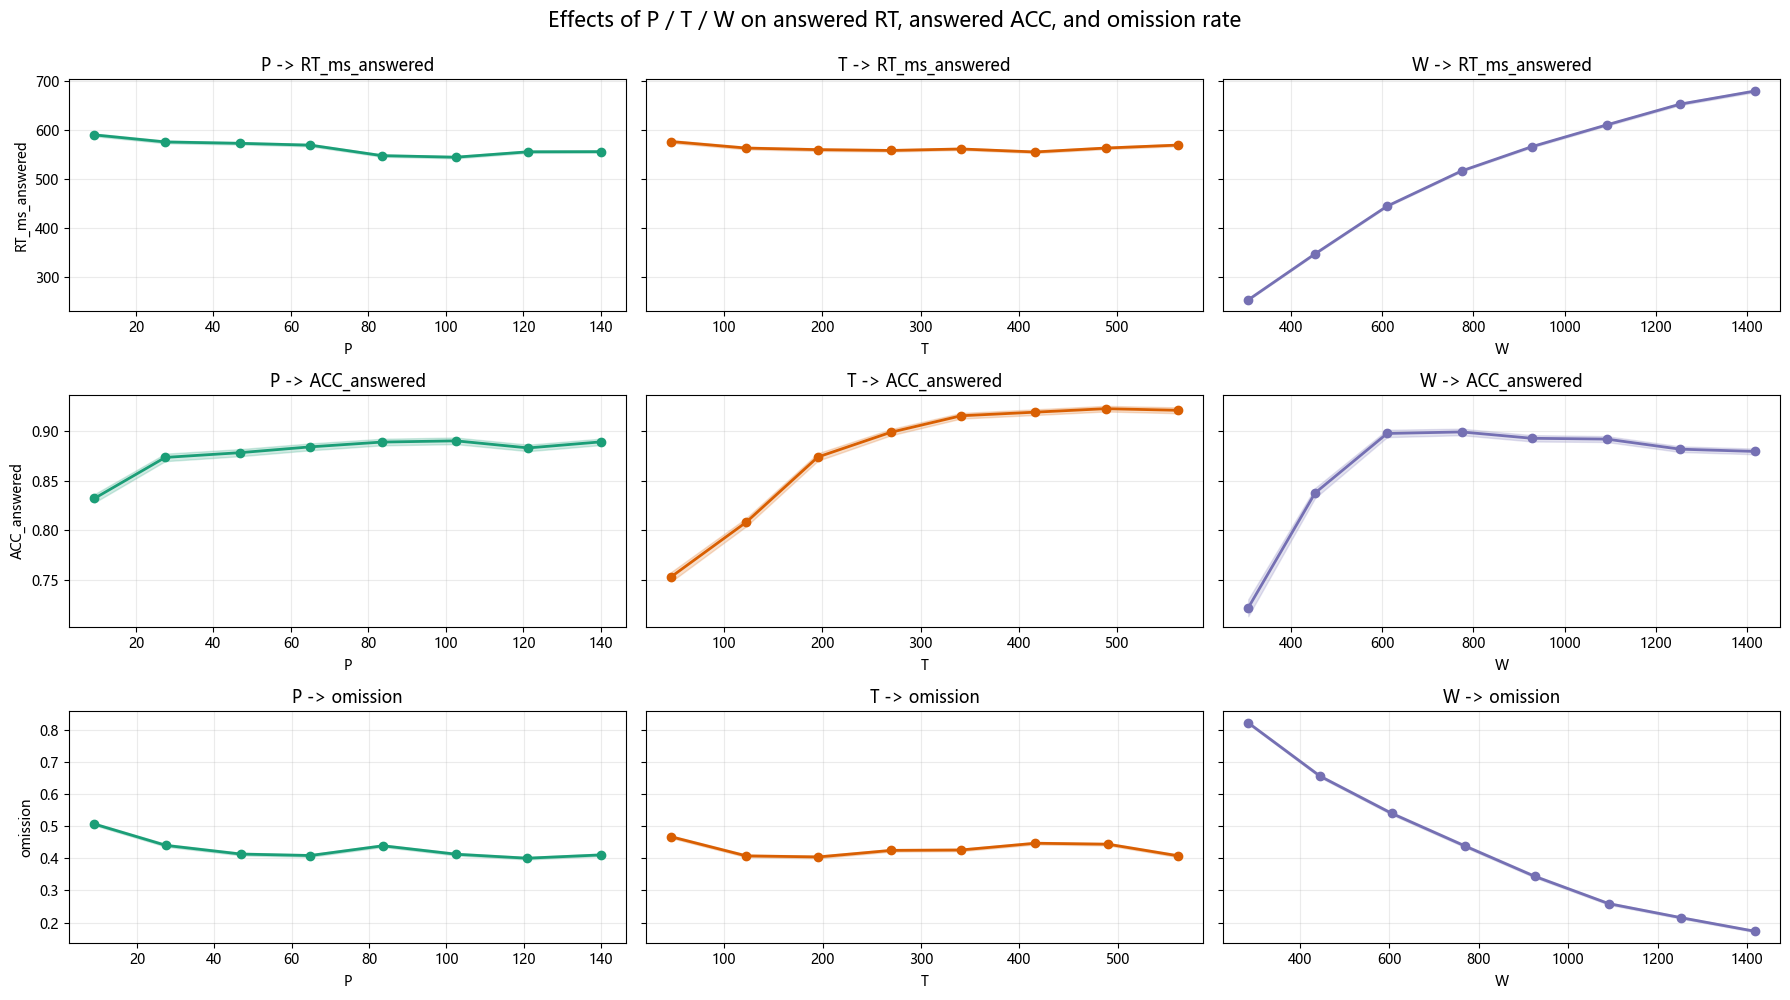

In [5]:
# 设计变量趋势
def summarize_by_bins(data, x_col, y_col, bins=8):
    temp = data[[x_col, y_col]].dropna().copy()
    temp['bin'] = pd.cut(temp[x_col], bins=bins, include_lowest=True, duplicates='drop')
    summary = (
        temp.groupby('bin', observed=False)
            .agg(
                x_mean=(x_col, 'mean'),
                y_mean=(y_col, 'mean'),
                y_std=(y_col, 'std'),
                n=(y_col, 'size')
            )
            .reset_index(drop=True)
    )
    summary['y_sem'] = summary['y_std'] / np.sqrt(summary['n'].clip(lower=1))
    return summary

def plot_design_effect_grid(data, x_vars, metrics, bins=8, figsize=(18, 12), title=None, save_path=None):
    fig, axes = plt.subplots(len(metrics), len(x_vars), figsize=figsize, sharey='row')
    if len(metrics) == 1:
        axes = np.array([axes])
    colors = {'P': '#1b9e77', 'T': '#d95f02', 'W': '#7570b3'}
    for i, metric in enumerate(metrics):
        for j, x_var in enumerate(x_vars):
            ax = axes[i, j]
            summary = summarize_by_bins(data, x_var, metric, bins=bins)
            ax.plot(summary['x_mean'], summary['y_mean'], marker='o', color=colors[x_var], linewidth=2)
            ax.fill_between(summary['x_mean'], summary['y_mean'] - summary['y_sem'], summary['y_mean'] + summary['y_sem'], color=colors[x_var], alpha=0.2)
            ax.set_xlabel(x_var)
            if j == 0:
                ax.set_ylabel(metric)
            ax.set_title(f'{x_var} -> {metric}')
            ax.grid(alpha=0.25)
    if title is not None:
        fig.suptitle(title, y=0.995, fontsize=15)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()

plot_design_effect_grid(
    data=df,
    x_vars=['P', 'T', 'W'],
    metrics=['v', 'a', 't0', 'z'],
    bins=8,
    figsize=(18, 14),
    title='Effects of P / T / W on latent DDM parameters',
    save_path=FIG_DIR / 'PTW_to_v_a_t_z_v2.4.5.png'
)

plot_design_effect_grid(
    data=df,
    x_vars=['P', 'T', 'W'],
    metrics=['RT_ms_answered', 'ACC_answered', 'omission'],
    bins=8,
    figsize=(18, 10),
    title='Effects of P / T / W on answered RT, answered ACC, and omission rate',
    save_path=FIG_DIR / 'PTW_to_RT_ACC_OMIT_v2.4.5.png'
)

## 二、这版修正的结论

异常原因已经明确：

- `v2.4.4` 的异常不是 NA 机制本身，而是 `a_final` 的硬截断造成了边界堆积；
- 边界堆积会让大量 trial 在 `t0` 之后立刻撞边界，形成过多的极短 RT。

`v2.4.5` 的修正方式是：

- 保留 NA 建模；
- 把 `a_final = max(0.1, a_final)` 改成正值重采样；
- 从而减少边界在同一个极小值上的堆积。

如果后面你还希望进一步压低最短 RT，可以继续考虑：

1. 给 `t0` 加少量个体/试次波动，而不是固定 0.2；
2. 减小 `a_noise`；
3. 给 `a` 设一个更有理论依据的下界，例如与 `W` 或 `T` 联动，而不是纯数值下界。